In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = r'wafer_23012020_041211.csv'
df = pd.read_csv(file_path)

In [3]:
df.head()

,Unnamed: 0,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5,Sensor-6,Sensor-7,Sensor-8,Sensor-9,...,Sensor-582,Sensor-583,Sensor-584,Sensor-585,Sensor-586,Sensor-587,Sensor-588,Sensor-589,Sensor-590,Good/Bad
0,Wafer-801,2968.33,2476.58,2216.7333,1748.0885,1.1127,100.0,97.5822,0.1242,1.5300,...,NaN,0.5004,0.0120,0.0033,2.4069,0.0545,0.0184,0.0055,33.7876,-1
1,Wafer-802,2961.04,2506.43,2170.0666,1364.5157,1.5447,100.0,96.7700,0.1230,1.3953,...,NaN,0.4994,0.0115,0.0031,2.3020,0.0545,0.0184,0.0055,33.7876,1
2,Wafer-803,3072.03,2500.68,2205.7445,1363.1048,1.0518,100.0,101.8644,0.1220,1.3896,...,NaN,0.4987,0.0118,0.0036,2.3719,0.0545,0.0184,0.0055,33.7876,-1
3,Wafer-804,3021.83,2419.83,2205.7445,1363.1048,1.0518,100.0,101.8644,0.1220,1.4108,...,NaN,0.4934,0.0123,0.0040,2.4923,0.0545,0.0184,0.0055,33.7876,-1
4,Wafer-805,3006.95,2435.34,2189.8111,1084.6502,1.1993,100.0,104.8856,0.1234,1.5094,...,NaN,0.4987,0.0145,0.0041,2.8991,0.0545,0.0184,0.0055,33.7876,-1


In [4]:
df.shape

(100, 592)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 592 entries, Unnamed: 0 to Good/Bad
dtypes: float64(494), int64(97), object(1)
memory usage: 462.6+ KB


In [6]:
df.dtypes

Unnamed: 0     object
Sensor-1      float64
Sensor-2      float64
Sensor-3      float64
Sensor-4      float64
               ...   
Sensor-587    float64
Sensor-588    float64
Sensor-589    float64
Sensor-590    float64
Good/Bad        int64
Length: 592, dtype: object

In [7]:
df.rename(columns={'Unnamed: 0':'Wafer'},inplace=True)

In [8]:
nr_of_row = df.shape[0]

In [9]:
df['Wafer'] = df['Wafer'].apply(lambda r:r.replace('Wafer-','')).astype(int)

In [10]:
df.columns

Index(['Wafer', 'Sensor-1', 'Sensor-2', 'Sensor-3', 'Sensor-4', 'Sensor-5',
       'Sensor-6', 'Sensor-7', 'Sensor-8', 'Sensor-9',
       ...
       'Sensor-582', 'Sensor-583', 'Sensor-584', 'Sensor-585', 'Sensor-586',
       'Sensor-587', 'Sensor-588', 'Sensor-589', 'Sensor-590', 'Good/Bad'],
      dtype='object', length=592)

In [11]:
reject_columns = df.columns[df.isna().sum()>=(nr_of_row*40)/100]

In [12]:
df.drop(reject_columns,axis=1,inplace=True)

In [13]:
df.shape

(100, 564)

In [14]:
df.isna().sum().sum()

np.int64(638)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
X = df.drop('Good/Bad', axis=1)
y = df['Good/Bad']

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [18]:
median  = X_train.median()
X_train = X_train.fillna(median)
X_test = X_test.fillna(median)

In [19]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)

IQR = Q3-Q1

lf = Q1 - 1.5 * IQR
uf = Q3 + 1.5 * IQR

median =  X_train.median()
outlier_mask = (X_train < lf) |(  X_train >uf)
for col in X_train.columns:
    X_train[col]= np.where(outlier_mask[col],median[col],X_train[col])


In [20]:
X_train

,Wafer,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5,Sensor-6,Sensor-7,Sensor-8,Sensor-9,...,Sensor-577,Sensor-578,Sensor-583,Sensor-584,Sensor-585,Sensor-586,Sensor-587,Sensor-588,Sensor-589,Sensor-590
63,864.0,3001.60,2405.62,2171.5000,1028.4440,0.7899,100.0,101.5122,0.1224,1.3481,...,1.2631,13.7684,0.5020,0.0127,0.0032,2.5214,0.02420,0.0094,0.0027,38.9642
9,810.0,2984.06,2619.60,2225.0222,1730.8480,1.5333,100.0,98.5978,0.1232,1.4696,...,2.0444,17.6552,0.4978,0.0133,0.0032,2.6765,0.01280,0.0193,0.0060,151.1930
35,836.0,2949.75,2528.50,2246.5778,1963.8016,1.1665,100.0,96.7089,0.1209,1.5070,...,2.0444,17.6552,0.4927,0.0147,0.0037,2.9826,0.04730,0.0280,0.0087,59.0825
52,853.0,3007.47,2571.18,2187.4111,1942.3069,1.1864,100.0,88.0911,0.1245,1.3746,...,1.8042,23.1735,0.5010,0.0111,0.0030,2.2248,0.02620,0.0123,0.0033,46.7092
98,899.0,2955.87,2541.89,2200.9556,1244.2899,1.1665,100.0,99.2922,0.1224,1.4493,...,1.9417,14.6551,0.5023,0.0140,0.0033,2.7810,0.01530,0.0048,0.0017,31.0176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,801.0,2968.33,2476.58,2216.7333,1748.0885,1.1127,100.0,97.5822,0.1242,1.5300,...,2.0444,17.6552,0.5004,0.0120,0.0033,2.4069,0.02145,0.0184,0.0055,33.7876
6,807.0,2953.59,2504.86,2224.6778,1308.6479,1.3907,100.0,101.1333,0.1208,1.4517,...,2.0351,15.1082,0.4963,0.0156,0.0038,3.1427,0.00990,0.0113,0.0038,114.2878
84,885.0,2977.29,2471.50,2214.7889,1687.4606,2.2073,100.0,97.3378,0.1226,1.5071,...,1.6245,13.2830,0.5080,0.0168,0.0039,3.3154,0.01340,0.0121,0.0035,90.4575
49,850.0,2998.89,2532.66,2189.3556,2363.6412,2.1415,100.0,99.2922,0.1246,1.4108,...,1.6245,13.2830,0.5022,0.0097,0.0027,1.9367,0.01470,0.0095,0.0028,65.0365


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=2)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [23]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()

In [24]:
log_reg.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
y_pred = log_reg.predict(X_test)

In [26]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      0.93      0.93        28
           1       0.00      0.00      0.00         2

    accuracy                           0.87        30
   macro avg       0.46      0.46      0.46        30
weighted avg       0.87      0.87      0.87        30



In [28]:
confusion_matrix(y_test,y_pred)

array([[26,  2],
       [ 2,  0]])

In [29]:
accuracy_score(y_test,y_pred)

0.8666666666666667

In [30]:
from sklearn.model_selection import GridSearchCV
params = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [1,4,5,45,68,98,9],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'max_iter':  [100,200,42,98]
}
gsv = GridSearchCV(estimator=log_reg,param_grid=params,cv=5,n_jobs=-1)

In [31]:
gsv.fit(X_train,y_train)
gsv.best_params_

{'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}

In [32]:
y_pred = gsv.predict(X_test)
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      0.93      0.93        28
           1       0.00      0.00      0.00         2

    accuracy                           0.87        30
   macro avg       0.46      0.46      0.46        30
weighted avg       0.87      0.87      0.87        30
 0.8666666666666667
[[26  2]
 [ 2  0]]


In [33]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)
y_pred = dtc.predict(X_test)

In [34]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      0.96      0.95        28
           1       0.00      0.00      0.00         2

    accuracy                           0.90        30
   macro avg       0.47      0.48      0.47        30
weighted avg       0.87      0.90      0.88        30
 0.9
[[27  1]
 [ 2  0]]


In [35]:
params = {
    'max_depth':[9,42,87,10,54,23],
    'min_samples_split':[2,5,7,4],
    'min_samples_leaf':[1,2,5,7,4],
    'max_features':['sqrt', 'log2'],
}

In [36]:
gsv_dtc = GridSearchCV(estimator=dtc,param_grid=params,cv = 5,n_jobs=-1)
gsv_dtc.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [9, 42, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [37]:
gsv_dtc.best_params_
y_pred = gsv.predict(X_test)

In [38]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      0.93      0.93        28
           1       0.00      0.00      0.00         2

    accuracy                           0.87        30
   macro avg       0.46      0.46      0.46        30
weighted avg       0.87      0.87      0.87        30
 0.8666666666666667
[[26  2]
 [ 2  0]]


In [39]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)

In [40]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      1.00      0.97        28
           1       0.00      0.00      0.00         2

    accuracy                           0.93        30
   macro avg       0.47      0.50      0.48        30
weighted avg       0.87      0.93      0.90        30
 0.9333333333333333
[[28  0]
 [ 2  0]]


In [41]:
params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],  # important for rbf/poly/sigmoid
    'degree': [2, 3, 4]          # only used for 'poly'
}

In [42]:
gsv_svc = GridSearchCV(estimator=svc,param_grid=params,cv = 5,n_jobs=-1)
gsv_svc.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'degree': [2, 3, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [43]:
print(gsv_svc.best_params_)
y_pred = gsv_svc.predict(X_test)

{'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}


In [44]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      0.93      0.93        28
           1       0.00      0.00      0.00         2

    accuracy                           0.87        30
   macro avg       0.46      0.46      0.46        30
weighted avg       0.87      0.87      0.87        30
 0.8666666666666667
[[26  2]
 [ 2  0]]


In [45]:
from sklearn.naive_bayes import GaussianNB
guassian = GaussianNB()
guassian.fit(X_train,y_train)
y_pred = guassian.predict(X_test)

In [46]:
guassian.predict_proba(X_test)

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [47]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      1.00      0.97        28
           1       0.00      0.00      0.00         2

    accuracy                           0.93        30
   macro avg       0.47      0.50      0.48        30
weighted avg       0.87      0.93      0.90        30
 0.9333333333333333
[[28  0]
 [ 2  0]]


In [48]:
params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}
gsv_bayes = GridSearchCV(estimator=guassian,param_grid=params,cv = 5,n_jobs=-1)
gsv_bayes.fit(X_train,y_train)

,estimator,GaussianNB()
,param_grid,"{'var_smoothing': [1e-09, 1e-08, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [49]:
gsv_bayes.best_params_
y_pred = gsv_bayes.predict(X_test)

In [50]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.93      1.00      0.97        28
           1       0.00      0.00      0.00         2

    accuracy                           0.93        30
   macro avg       0.47      0.50      0.48        30
weighted avg       0.87      0.93      0.90        30
 0.9333333333333333
[[28  0]
 [ 2  0]]


In [51]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(oob_score=True)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)

In [52]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(rfc.oob_score_)

              precision    recall  f1-score   support

          -1       0.93      1.00      0.97        28
           1       0.00      0.00      0.00         2

    accuracy                           0.93        30
   macro avg       0.47      0.50      0.48        30
weighted avg       0.87      0.93      0.90        30
 0.9333333333333333
[[28  0]
 [ 2  0]]
1.0


In [53]:
params = {
   'max_depth':[9,4,8,10],
   'max_features':['sqrt', 'log2'],
}
gsv_bag = GridSearchCV(estimator=rfc,param_grid=params,cv = 5,n_jobs=-1)
gsv_bag.fit(X_train,y_train)

,estimator,RandomForestC...ob_score=True)
,param_grid,"{'max_depth': [9, 4, ...], 'max_features': ['sqrt', 'log2']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [54]:
y_pred = gsv_bag.predict(X_test)
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(rfc.oob_score_)


              precision    recall  f1-score   support

          -1       0.93      1.00      0.97        28
           1       0.00      0.00      0.00         2

    accuracy                           0.93        30
   macro avg       0.47      0.50      0.48        30
weighted avg       0.87      0.93      0.90        30
 0.9333333333333333
[[28  0]
 [ 2  0]]
1.0


In [66]:
# from sklearn.ensemble import GradientBoostingClassifier
# gbc = GradientBoostingClassifier()
df.columns[0:50]

Index(['Wafer', 'Sensor-1', 'Sensor-2', 'Sensor-3', 'Sensor-4', 'Sensor-5',
       'Sensor-6', 'Sensor-7', 'Sensor-8', 'Sensor-9', 'Sensor-10',
       'Sensor-11', 'Sensor-12', 'Sensor-13', 'Sensor-14', 'Sensor-15',
       'Sensor-16', 'Sensor-17', 'Sensor-18', 'Sensor-19', 'Sensor-20',
       'Sensor-21', 'Sensor-22', 'Sensor-23', 'Sensor-24', 'Sensor-25',
       'Sensor-26', 'Sensor-27', 'Sensor-28', 'Sensor-29', 'Sensor-30',
       'Sensor-31', 'Sensor-32', 'Sensor-33', 'Sensor-34', 'Sensor-35',
       'Sensor-36', 'Sensor-37', 'Sensor-38', 'Sensor-39', 'Sensor-40',
       'Sensor-41', 'Sensor-42', 'Sensor-43', 'Sensor-44', 'Sensor-45',
       'Sensor-46', 'Sensor-47', 'Sensor-48', 'Sensor-49'],
      dtype='object')

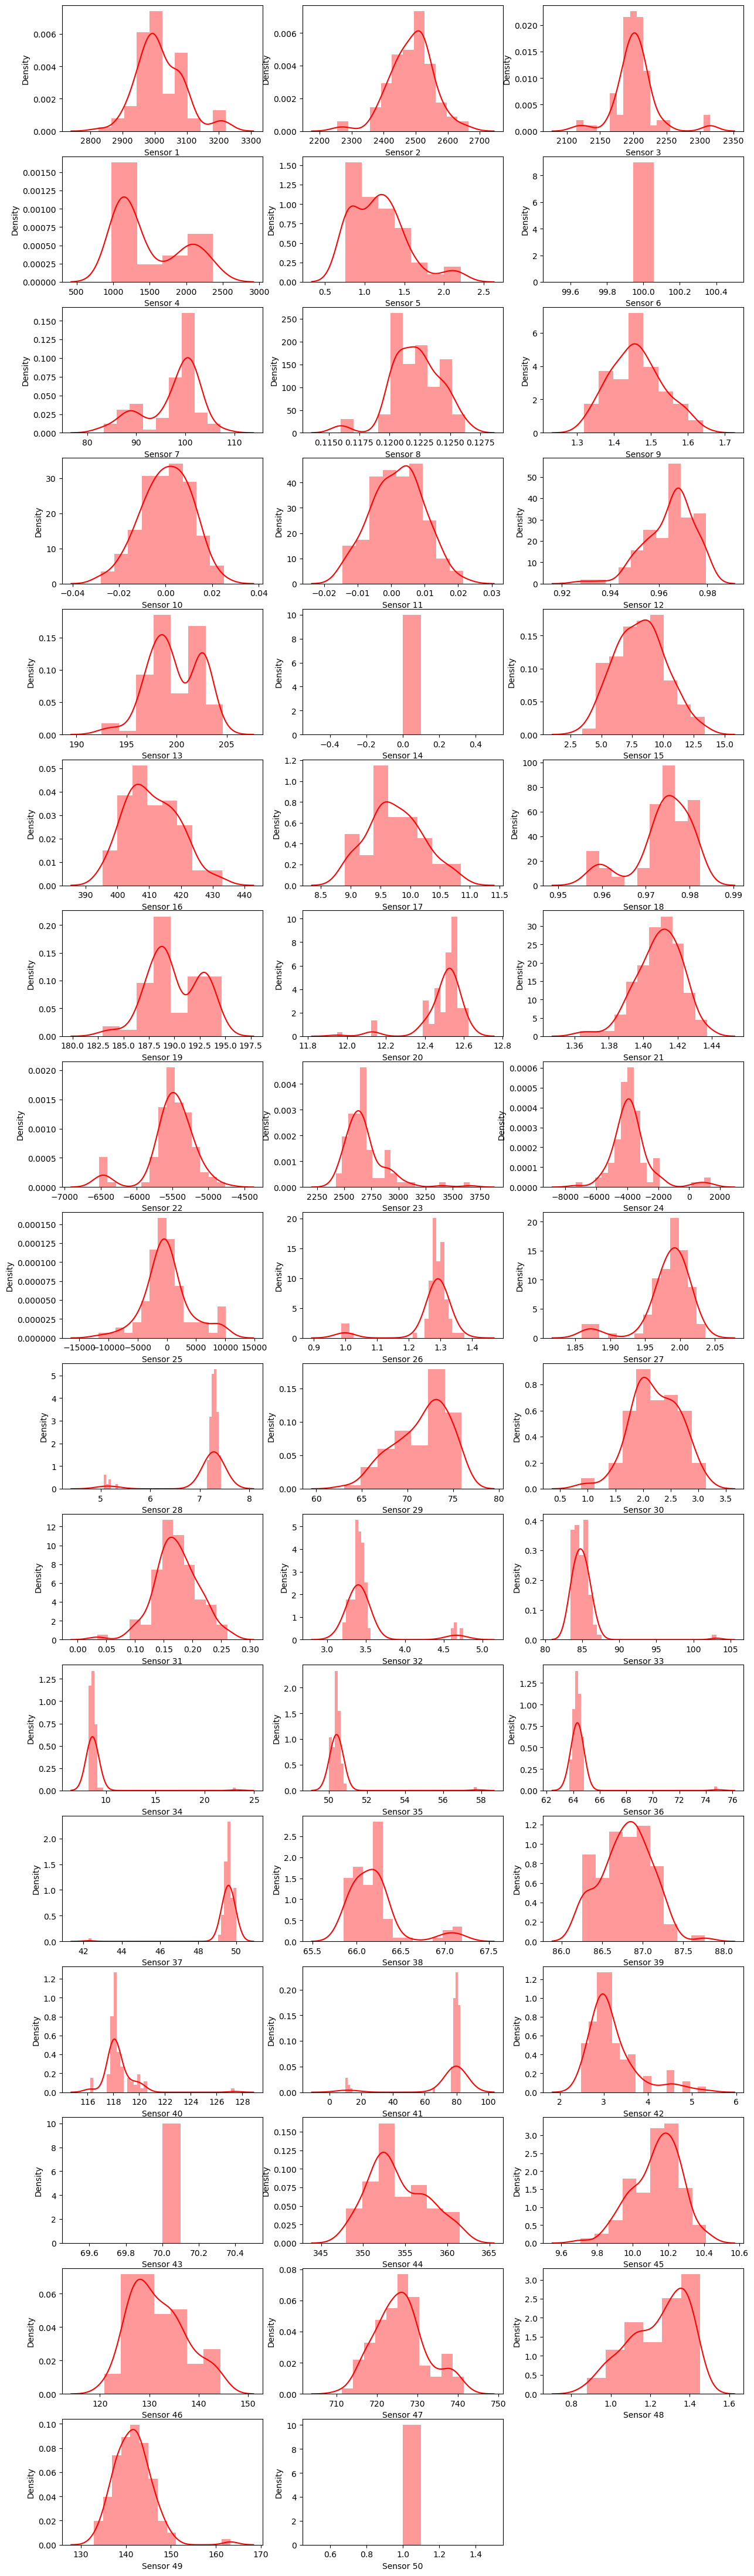

In [77]:
# visualisation
plt.figure(figsize=(15,200))
for i,col in enumerate(df.columns[1:51]):
    plt.subplot(60,3,i+1)
    sns.distplot(x=df[col],color='red')
    plt.xlabel(f'Sensor {i+1}')
